In [1]:
%load_ext autoreload
%autoreload 2
import cooler
import pandas as pd

res = 12800
# res = 12800

cool_nc18 = cooler.Cooler(f'./cools/nc1-8_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_nc14 = cooler.Cooler(f'./cools/nc14_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_s10 = cooler.Cooler(f'./cools/s10-12_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')

In [2]:
%load_ext autoreload
%autoreload
import scanpy as sc
import sys

sys.path.append('./code2')

from hic_zscore_functions import make_obs_exp_intra
from aux_functions import *
from plotting_functions import *

sc.settings.set_figure_params(dpi=80, color_map='coolwarm', frameon=True)
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"axes.grid.axis" : 'both'})
plt.rcParams.update({"axes.grid" : True})

plt.rcParams.update({
    'axes.labelsize': 14,       # x and y labels' font size
    'xtick.labelsize': 8,      # x tick labels' font size
    'ytick.labelsize': 8,      # y tick labels' font size
    'axes.titlesize': 14,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'legend.fontsize': 6,      # Legend font size
})
plt.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'axes.labelsize': 8,       # x and y labels' font size
    'xtick.labelsize': 6,      # x tick labels' font size
    'ytick.labelsize': 6,      # y tick labels' font size
    'axes.titlesize': 10,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'xtick.major.pad' : 2,
    'ytick.major.pad' : 2,

})
plt.rcParams['axes.linewidth'] = .25
plt.rcParams['xtick.major.width'] = .25
plt.rcParams['ytick.major.width'] = .25
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['grid.linewidth'] = .25

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from config import load_cses, load_loop_anchors
from config import rgb_to_cluster, cluster_to_rgb

all_cses = load_cses()
all_loop_anchors = load_loop_anchors()

In [4]:
def make_figure3b():
    colsoi = ['mE_mRNA_em0-2hr', 'mE_mRNA_em2-4hr', 'mE_mRNA_em4-6hr', 'mE_mRNA_em6-8hr', 'mE_mRNA_em8-10hr', 'mE_mRNA_em10-12hr', 'mE_mRNA_em12-14hr', 'mE_mRNA_em14-16hr', 'mE_mRNA_em16-18hr', 'mE_mRNA_em18-20hr', 'mE_mRNA_em20-22hr', 'mE_mRNA_em22-24hr',]
    rna_seq_data = pd.read_csv('../annotations/gene_rpkm_matrix_fb_2021_03.tsv', sep='\t',
               skiprows=4,
               skipfooter=1)
    rna_seq_data = rna_seq_data[rna_seq_data['gene_type'] == 'protein_coding_gene']
    rna_seq_data = rna_seq_data.set_index('gene_symbol').drop(['#gene_primary_id', 'gene_fullname', 'gene_type'], axis=1)
    rna_seq_data.columns = [x.split("_(")[0] for x in rna_seq_data.columns]
    rna_seq_data = rna_seq_data[colsoi]
    rna_seq_data = rna_seq_data.dropna() 
    rna_seq_data.index = rna_seq_data.index.astype(str)
    housekeeping_genes = pd.Series(sorted(rna_seq_data[(rna_seq_data.rank(axis=0) > 3000).all(axis=1)].index))
    
    genes = pbt.BedTool('../for_annotations/dmel-6.39.gtf').filter(lambda x: x[2]=='gene'
                    ).filter(lambda x: 'pre-mod' not in x[-1]
                    ).filter(lambda x: '5Sr' not in x[-1]
                    ).filter(lambda x: 'sno' not in x[-1]).saveas(
                    ).saveas().to_dataframe()
    
    genes = genes[genes['strand'] == '+']
    genes = genes[genes['seqname'].isin(['3L', '2L', '3R', '2R',])]
    # genes = genes[['seqname', 'start', 'end']]
    
    genes['gene_name'] = [x.split('"')[-2] for x in genes['attributes']]
    genes.index = genes['seqname'] + "_" + genes['start'].astype(str) + "_" + genes['end'].astype(str)
    
    housekeeping_gene_bedtool = pbt.BedTool.from_dataframe(genes[genes['gene_name'].isin(housekeeping_genes)])
    non_housekeeping_gene_bedtool = pbt.BedTool.from_dataframe(genes[~genes['gene_name'].isin(housekeeping_genes)])
    
    fig, axs = init_subplots_exact(1, 1, fgsz=(40*mm, 40*mm), dpi = 150)
    
    
    results = []
    for u in [0, 1, 2, 3]:
        subdf = all_cses[all_cses['cluster'] == u]
        p_house = bedprop(housekeeping_gene_bedtool, pbt.BedTool.from_dataframe(subdf[['chrom', 'start', 'end']]))
        ntot_house = len(housekeeping_gene_bedtool)
        n_house = ntot_house*p_house
    
        p_nonhouse = bedprop(non_housekeeping_gene_bedtool, pbt.BedTool.from_dataframe(subdf[['chrom', 'start', 'end']]))
        ntot_nonhouse = len(non_housekeeping_gene_bedtool)
        n_nonhouse = ntot_nonhouse*p_nonhouse
        
        result = [u, p_house, n_house, ntot_house, p_nonhouse, n_nonhouse, ntot_nonhouse]
        results.append(result)
        
    subdf = all_cses
    p_house = bedprop(housekeeping_gene_bedtool, pbt.BedTool.from_dataframe(subdf[['chrom', 'start', 'end']]))
    ntot_house = len(housekeeping_gene_bedtool)
    n_house = ntot_house*p_house
    
    p_nonhouse = bedprop(non_housekeeping_gene_bedtool, pbt.BedTool.from_dataframe(subdf[['chrom', 'start', 'end']]))
    ntot_nonhouse = len(non_housekeeping_gene_bedtool)
    n_nonhouse = ntot_nonhouse*p_nonhouse
    
    baseline_result = ['baseline', p_house, n_house, ntot_house, p_nonhouse, n_nonhouse, ntot_nonhouse]
    results.append(baseline_result)
    results = pd.DataFrame(results, columns = ['condition', 'p_house', 'n_house', 'ntot_house',
                                              'p_nonhouse', 'n_nonhouse', 'ntot_nonhouse']).set_index('condition')
    
    
    for u in [0, 1, 2, 3]:
        plt.bar(f'Cluster {u}', results.loc[u, 'p_house'], color=cluster_to_rgb[u],
               edgecolor='black')
        _, p = scipy.stats.fisher_exact([
            [results.loc[u, 'n_house'], results.loc[u, 'n_nonhouse']],
            [results.drop(u).sum()['n_house'], results.drop(u).sum()['n_nonhouse']]
        ], alternative='greater')
        print(f'{u}; p={p}, {_}')
        plt.xticks(rotation=20)

/tmp/ipykernel_2869247/2343198205.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  rna_seq_data = pd.read_csv('../annotations/gene_rpkm_matrix_fb_2021_03.tsv', sep='\t',


0; p=1.0, 0.35704195804195804
1; p=0.9999997451091792, 0.502516958997232
2; p=2.940196478254837e-26, 2.444886189872865
3; p=0.270186648862906, 1.1462450964713409


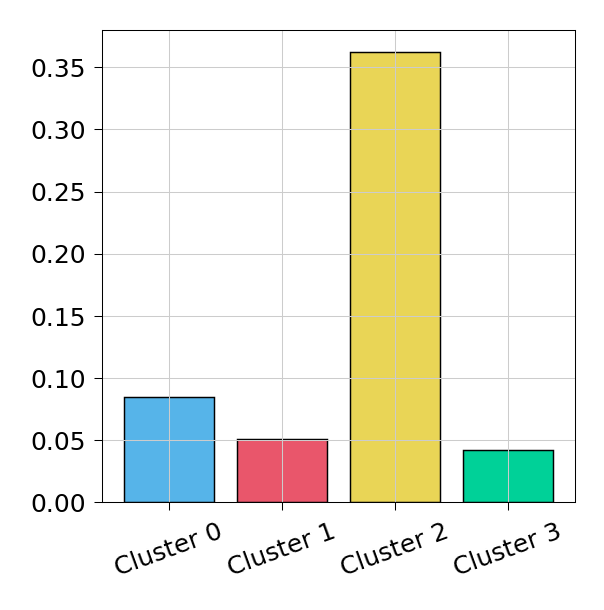

In [5]:
make_figure3b()